In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path1 = "/content/drive/My Drive/ICT108/ICT108_Week 8/Daily_Minimum_Temperature_in_Melbourne.csv"
file_path2 = "/content/drive/My Drive/ICT108/ICT108_Week 8/mock_kaggle.csv"

df_naive = pd.read_csv(file_path1)
df_sma = pd.read_csv(file_path2)

print("Naive Forecasting Dataset columns:", df_naive.columns)
print("SMA Dataset columns:", df_sma.columns)

Naive Forecasting Dataset columns: Index(['Date', 'Temperature'], dtype='object')
SMA Dataset columns: Index(['data', 'venda', 'estoque', 'preco'], dtype='object')


In [ ]:
df_naive.columns = df_naive.columns.str.strip()

df_sma.columns = df_sma.columns.str.strip()

# For Naive Forecasting Dataset - Confirm 'Date' column exists

if 'Date'in df_naive.columns:
  df_naive['Date'] = pd.to_datetime(df_naive['Date'], dayfirst=True, errors='coerce')
  df_naive.set_index('Date', inplace=True)
else:
  print("Error: 'Date' column not found in Naive Forecasting dataset")

# For SMA Dataset - Confirm 'data' column exist

if 'data' in df_sma.columns:
  df_sma['data'] = pd.to_datetime(df_sma['data'], dayfirst=True, errors='coerce')
  df_sma.set_index('data', inplace=True)
else:
  print("Error: 'data' column not found in SMA dataset")

# Forward-fill missing values

df_naive = df_naive.fillna(method='ffill')
df_sma = df_sma.fillna(method='ffill')

Error: 'Date' column not found in Naive Forecasting dataset
Error: 'data' column not found in SMA dataset


In [ ]:
# Task	8
#	Define	the	Naive	Forecast	Function,	Implement	the	function	and	Determine	the	metrics
#	Assuming	df_naive	is	already	loaded	and	has	the	'Temperature'	column
#	Step	1:	Convert	non-numeric	values	in	'Temperature'	to	NaN
df_naive['Temperature']	=	pd.to_numeric(df_naive['Temperature'],	errors='coerce')

#	Step	2:	Fill	NaN	values	in	'Temperature'	using	forward-fill
df_naive['Temperature'].fillna(method='ffill',	inplace=True)

#	Create	a	naive	forecast	by	shifting	the	temperature	column
df_naive['Naive_Forecast']	=	df_naive['Temperature'].shift(1)
df_naive.dropna(inplace=True)	#	Drop	the	first	row	as	it	will	have	NaN	for	forecast

#	Calculate	Mean	Absolute	Error
mae	=	mean_absolute_error(df_naive['Temperature'],	df_naive['Naive_Forecast'])
print("MAE	for	Naive	Forecasting:",	mae)


MAE	for	Naive	Forecasting: 2.1324472458207726


In [ ]:
#	Task	9
#	Application	of	Simple	Moving	Average	(SMA)

#	Define	window	size	for	SMA
#	Define	the	window	size	for	SMA
window_size	=	7
df_sma['SMA']	=	df_sma['venda'].rolling(window=window_size).mean()
df_sma.dropna(inplace=True)	#	Drop	initial	NaN	values	resulting	from	SMA	calculation

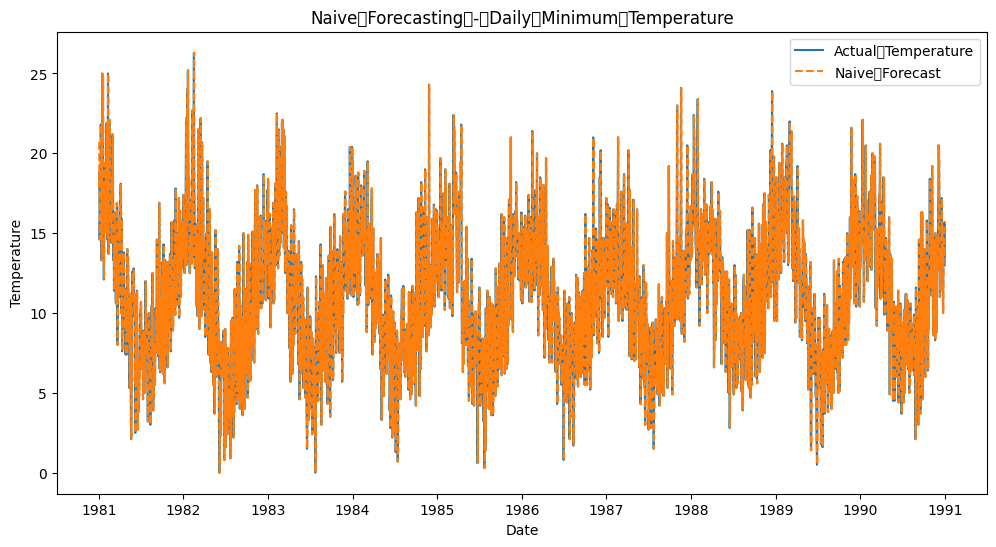

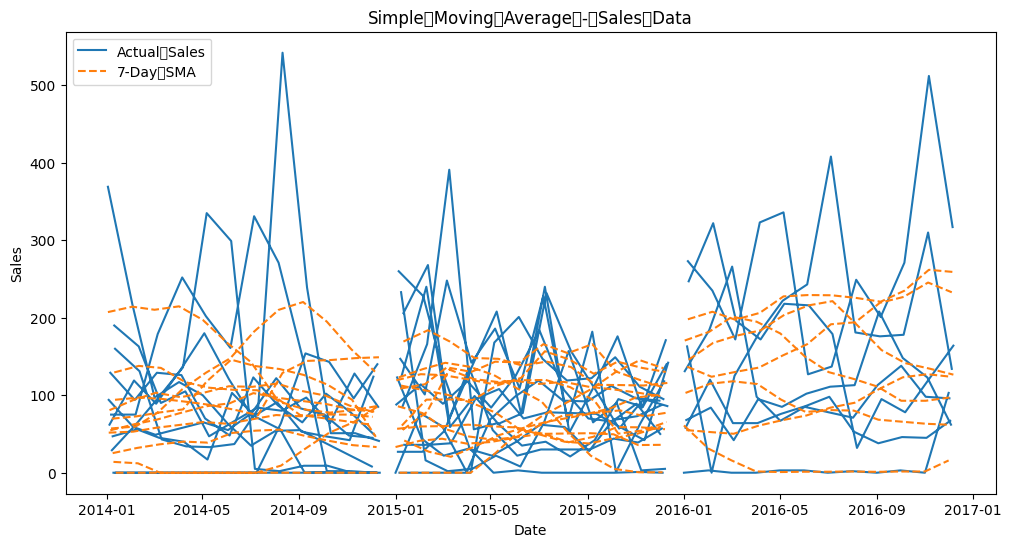

In [ ]:
#Task	10
#	Visualise	the	forcast

#	Naive	Forecasting	Visualization
plt.figure(figsize=(12,	6))
plt.plot(df_naive['Temperature'],	label='Actual	Temperature')
plt.plot(df_naive['Naive_Forecast'],	label='Naive	Forecast',	linestyle='--')
plt.title('Naive	Forecasting	-	Daily	Minimum	Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

#	SMA	Visualization
plt.figure(figsize=(12,	6))
plt.plot(df_sma['venda'],	label='Actual	Sales')
plt.plot(df_sma['SMA'],	label=f'{window_size}-Day	SMA',	linestyle='--')
plt.title('Simple	Moving	Average	-	Sales	Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()
plt.show()